In [ ]:
!pwd

/kaggle/working


In [ ]:
!pip install -U keras-cv tensorflow
!pip install -U efficientnet
!pip install keras-cv
!pip install   scikit-optimize optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 620.7/620.7 MB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 98.5 MB/s eta 0:00:00
  Attempting uninstall: tensorboard
    Found existing installation: tensorboard 2.19.0
    Uninstalling tensorboard-2.19.0:
      Successfully uninstalled tensorboard-2.19.0
  Attempting uninstall: tensorflow
    Found existing installation: tensorflow 2.19.0
    Uninstalling tensorflow-2.19.0:
      Successfully uninstalled tensorflow-2.19.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dopamine-rl 4.1.2 requires gymnasium>=1.0.0, but you have gymnasium 0.29.0 which is incompatible.
tensorflow-text 2.19.0 requires tensorflow<2.20,>=2.19.0, but you have tensorflow 2.20.0 which is incompatible.
tensorflow-decision-forests 1.12.0 requires tensorflow==2.19.0, but you have tensorflow 2.20.0 which is incompat

MobileNetV2 + ViT-B/16

GPU CONFIGURATION CHECK
✅ GPU Available: 2 device(s)
   - PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')
   - PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')
✅ Memory growth enabled

TensorFlow version: 2.20.0
Keras version: 3.10.0
Built with CUDA: True
Instructions for updating:
Use `tf.config.list_physical_devices('GPU')` instead.
GPU Available for TensorFlow: True

🎲 Global seed set to: 42

TRAINING CONFIGURATION
Image Size: (224, 224)
Batch Size: 64
Epochs: 20
Learning Rate: 0.0001

LOADING DATA


I0000 00:00:1767599645.275003      24 gpu_device.cc:2020] Created device /device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1767599645.275710      24 gpu_device.cc:2020] Created device /device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 16800 images belonging to 3 classes.
Found 3600 images belonging to 3 classes.

📁 Dataset Info:
   Classes: ['one_molecule', 'reactions', 'several_molecules']
   Number of classes: 3
   Training samples: 16800
   Validation samples: 3600

BUILDING MODEL: MobileNetV2 + ViT-B/16


I0000 00:00:1767599656.280940      24 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1767599656.281154      24 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

📋 Model Summary:


...

197/263 ━━━━━━━━━━━━━━━━━━━━ 2:21 2s/step - accuracy: 0.7118 - loss: 0.7836

2026-01-05 08:02:57.313643: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-05 08:02:57.451282: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


263/263 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7306 - loss: 0.7356

2026-01-05 08:06:40.817598: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-05 08:06:40.958612: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


263/263 ━━━━━━━━━━━━━━━━━━━━ 744s 3s/step - accuracy: 0.7308 - loss: 0.7350 - val_accuracy: 0.8403 - val_loss: 0.4323 - learning_rate: 1.0000e-04
Epoch 2/20
263/263 ━━━━━━━━━━━━━━━━━━━━ 617s 2s/step - accuracy: 0.8440 - loss: 0.4331 - val_accuracy: 0.8614 - val_loss: 0.3698 - learning_rate: 1.0000e-04
Epoch 3/20
263/263 ━━━━━━━━━━━━━━━━━━━━ 615s 2s/step - accuracy: 0.8769 - loss: 0.3404 - val_accuracy: 0.8767 - val_loss: 0.3347 - learning_rate: 1.0000e-04
Epoch 4/20
263/263 ━━━━━━━━━━━━━━━━━━━━ 615s 2s/step - accuracy: 0.8817 - loss: 0.3109 - val_accuracy: 0.8900 - val_loss: 0.3077 - learning_rate: 1.0000e-04
Epoch 5/20
263/263 ━━━━━━━━━━━━━━━━━━━━ 615s 2s/step - accuracy: 0.8891 - loss: 0.2956 - val_accuracy: 0.8800 - val_loss: 0.3454 - learning_rate: 1.0000e-04
Epoch 6/20
263/263 ━━━━━━━━━━━━━━━━━━━━ 616s 2s/step - accuracy: 0.9030 - loss: 0.2607 - val_accuracy: 0.9047 - val_loss: 0.2768 - learning_rate: 1.0000e-04
Epoch 7/20
263/263 ━━━━━━━━━━━━━━━━━━━━ 615s 2s/step - accuracy: 0.91

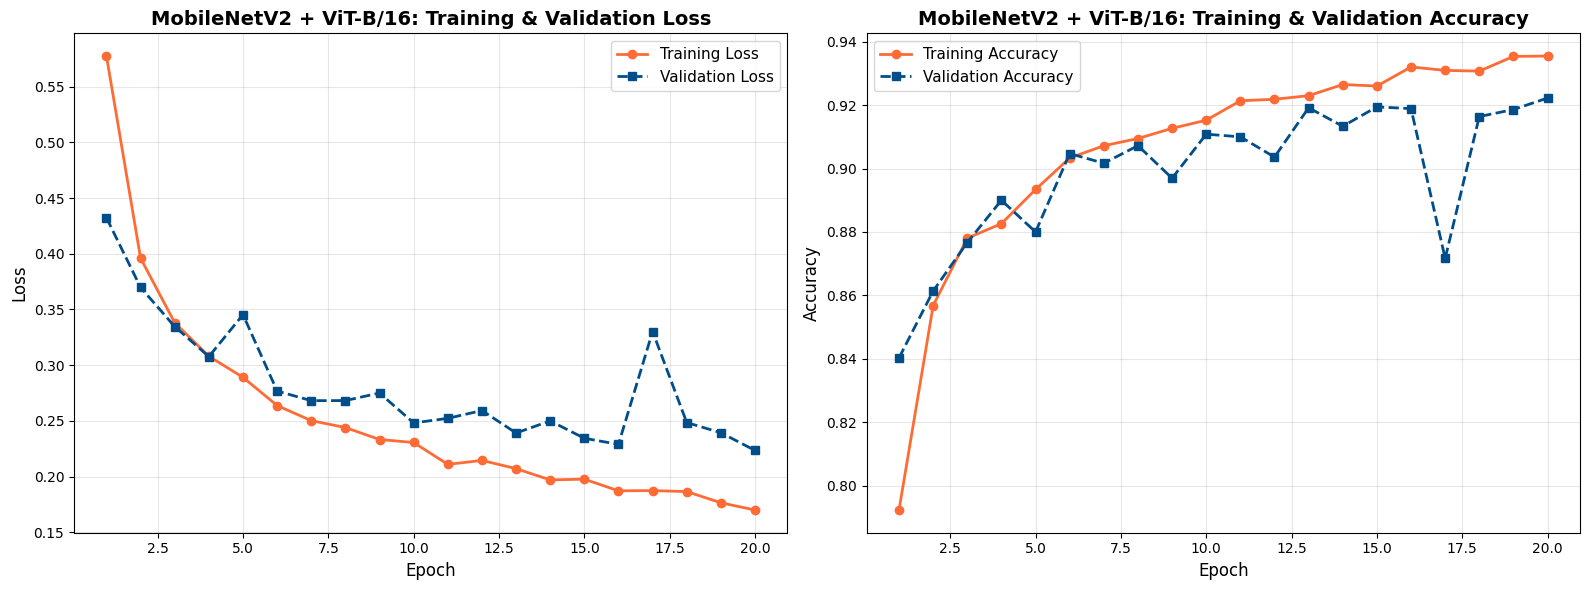


📊 EVALUATION ON VALIDATION SET
57/57 ━━━━━━━━━━━━━━━━━━━━ 53s 798ms/step

📈 PERFORMANCE METRICS
Accuracy:  92.22%
Precision: 92.23%
Recall:    92.22%
F1-Score:  92.23%

⏱️  Inference Time: 53.33s
⚡ Avg Time per Sample: 14.81ms

📋 DETAILED CLASSIFICATION REPORT
                   precision    recall  f1-score   support

     one_molecule     0.9454    0.9383    0.9419      1200
        reactions     0.9066    0.9142    0.9104      1200
several_molecules     0.9149    0.9142    0.9145      1200

         accuracy                         0.9222      3600
        macro avg     0.9223    0.9222    0.9223      3600
     weighted avg     0.9223    0.9222    0.9223      3600



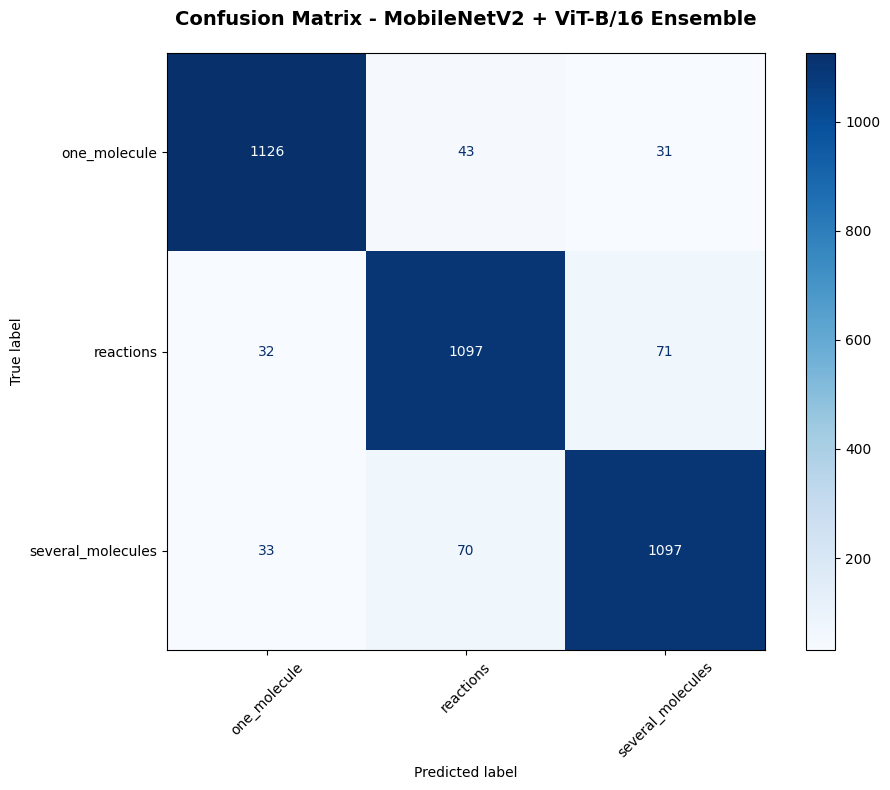


🎉 ENSEMBLE MODEL 1 EXECUTION COMPLETE!
Model: MobileNetV2 + ViT-B/16
Training Time: 207m 8s
Final Validation Accuracy: 92.22%
F1-Score: 92.23%


In [ ]:
"""
Ensemble Model 1: MobileNetV2 + ViT-B/16
Chemical Image Classification
GPU-Optimized for Kaggle T4
"""

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import precision_score, recall_score, f1_score
import random
import time

# GPU Configuration and Verification
print("="*70)
print("GPU CONFIGURATION CHECK")
print("="*70)
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"✅ GPU Available: {len(gpus)} device(s)")
    for gpu in gpus:
        print(f"   - {gpu}")
    # Enable memory growth to prevent OOM
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print("✅ Memory growth enabled")
else:
    print("⚠️  No GPU detected! Running on CPU")

print(f"\nTensorFlow version: {tf.__version__}")
print(f"Keras version: {keras.__version__}")

# Check if GPU is being used
print(f"Built with CUDA: {tf.test.is_built_with_cuda()}")
print(f"GPU Available for TensorFlow: {tf.test.is_gpu_available()}")

# Set seeds
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
print(f"\n🎲 Global seed set to: {SEED}")

# Configuration
TRAIN_DIR = "/kaggle/input/chemical-image-preprocessed/Preprocessed/train"
VAL_DIR = "/kaggle/input/chemical-image-preprocessed/Preprocessed/validation"
TEST_DIR = "/kaggle/input/chemical-image-preprocessed/Preprocessed/test"
IMG_SIZE = (224, 224)
BATCH_SIZE = 64
EPOCHS = 20
LEARNING_RATE = 0.0001

print("\n" + "="*70)
print("TRAINING CONFIGURATION")
print("="*70)
print(f"Image Size: {IMG_SIZE}")
print(f"Batch Size: {BATCH_SIZE}")
print(f"Epochs: {EPOCHS}")
print(f"Learning Rate: {LEARNING_RATE}")

# Data generators
print("\n" + "="*70)
print("LOADING DATA")
print("="*70)

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=SEED
)

val_generator = val_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

num_classes = len(train_generator.class_indices)
class_names = list(train_generator.class_indices.keys())
print(f"\n📁 Dataset Info:")
print(f"   Classes: {class_names}")
print(f"   Number of classes: {num_classes}")
print(f"   Training samples: {train_generator.n}")
print(f"   Validation samples: {val_generator.n}")

# Build Vision Transformer B/16
def create_vit_b16(input_shape, num_classes):
    """Vision Transformer Base/16 architecture"""
    inputs = layers.Input(shape=input_shape)

    # Patch embedding (16x16 patches)
    patch_size = 16
    num_patches = (input_shape[0] // patch_size) * (input_shape[1] // patch_size)
    projection_dim = 768

    # Create patches
    patches = layers.Conv2D(projection_dim, kernel_size=patch_size, strides=patch_size, padding='valid')(inputs)
    patches = layers.Reshape((num_patches, projection_dim))(patches)

    # Position embeddings
    positions = tf.range(start=0, limit=num_patches, delta=1)
    pos_embedding = layers.Embedding(input_dim=num_patches, output_dim=projection_dim)(positions)
    x = patches + pos_embedding

    # Transformer encoder blocks (10 blocks for efficiency)
    num_transformer_blocks = 10
    num_heads = 12
    mlp_dim = 3072

    for _ in range(num_transformer_blocks):
        # Layer normalization
        x1 = layers.LayerNormalization(epsilon=1e-6)(x)

        # Multi-head attention
        attention_output = layers.MultiHeadAttention(
            num_heads=num_heads,
            key_dim=projection_dim // num_heads,
            dropout=0.1
        )(x1, x1)

        # Skip connection
        x2 = layers.Add()([attention_output, x])

        # Layer normalization
        x3 = layers.LayerNormalization(epsilon=1e-6)(x2)

        # MLP
        x3 = layers.Dense(mlp_dim, activation=tf.nn.gelu)(x3)
        x3 = layers.Dropout(0.1)(x3)
        x3 = layers.Dense(projection_dim)(x3)
        x3 = layers.Dropout(0.1)(x3)

        # Skip connection
        x = layers.Add()([x3, x2])

    # Final layer normalization
    x = layers.LayerNormalization(epsilon=1e-6)(x)
    x = layers.GlobalAveragePooling1D()(x)

    return Model(inputs=inputs, outputs=x, name='ViT_B16')

# Build Ensemble Model
def create_ensemble_model(input_shape, num_classes):
    """MobileNetV2 + ViT-B/16 Ensemble"""
    inputs = layers.Input(shape=input_shape)

    # Branch 1: MobileNetV2 (CNN)
    mobilenet = MobileNetV2(
        include_top=False,
        weights='imagenet',
        input_shape=input_shape,
        pooling='avg'
    )
    mobilenet.trainable = False  # Freeze initially
    mobile_output = mobilenet(inputs)

    # Branch 2: ViT-B/16 (Transformer)
    vit_model = create_vit_b16(input_shape, num_classes)
    vit_output = vit_model(inputs)

    # Fusion Layer
    concat = layers.Concatenate(name='feature_fusion')([mobile_output, vit_output])

    # Classification Head
    x = layers.Dense(512, activation='relu', name='fusion_dense1')(concat)
    x = layers.BatchNormalization(name='fusion_bn1')(x)
    x = layers.Dropout(0.4, name='fusion_dropout1')(x)

    x = layers.Dense(256, activation='relu', name='fusion_dense2')(x)
    x = layers.BatchNormalization(name='fusion_bn2')(x)
    x = layers.Dropout(0.3, name='fusion_dropout2')(x)

    outputs = layers.Dense(num_classes, activation='softmax', name='output')(x)

    return Model(inputs=inputs, outputs=outputs, name='MobileNetV2_ViT_Ensemble')

# Create model
print("\n" + "="*70)
print("BUILDING MODEL: MobileNetV2 + ViT-B/16")
print("="*70)

model = create_ensemble_model(IMG_SIZE + (3,), num_classes)

# Compile model
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Model summary
print("\n📋 Model Summary:")
model.summary()

# Plot model architecture
print("\n🎨 Generating model architecture diagram...")
try:
    tf.keras.utils.plot_model(
        model,
        to_file='mobilenetv2_vit_ensemble_architecture.png',
        show_shapes=True,
        show_layer_names=True,
        show_dtype=True,
        dpi=96,
        expand_nested=False
    )
    print("✅ Architecture saved as 'mobilenetv2_vit_ensemble_architecture.png'")
except Exception as e:
    print(f"⚠️  Could not save architecture diagram: {e}")

# Callbacks
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    )
]

# Training
print("\n" + "="*70)
print("🚀 STARTING TRAINING")
print("="*70)

start_time = time.time()

history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=callbacks,
    verbose=1
)

training_time = time.time() - start_time

print("\n" + "="*70)
print("✅ TRAINING COMPLETE!")
print("="*70)
print(f"⏱️  Total Training Time: {training_time//60:.0f}m {training_time%60:.0f}s")

# Plot training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

epochs_range = range(1, len(history.history['loss']) + 1)

ax1.plot(epochs_range, history.history['loss'], 'o-', color='#FF6B35', label='Training Loss', linewidth=2, markersize=6)
ax1.plot(epochs_range, history.history['val_loss'], 's--', color='#004E89', label='Validation Loss', linewidth=2, markersize=6)
ax1.set_title("MobileNetV2 + ViT-B/16: Training & Validation Loss", fontsize=14, fontweight='bold')
ax1.set_xlabel("Epoch", fontsize=12)
ax1.set_ylabel("Loss", fontsize=12)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

ax2.plot(epochs_range, history.history['accuracy'], 'o-', color='#FF6B35', label='Training Accuracy', linewidth=2, markersize=6)
ax2.plot(epochs_range, history.history['val_accuracy'], 's--', color='#004E89', label='Validation Accuracy', linewidth=2, markersize=6)
ax2.set_title("MobileNetV2 + ViT-B/16: Training & Validation Accuracy", fontsize=14, fontweight='bold')
ax2.set_xlabel("Epoch", fontsize=12)
ax2.set_ylabel("Accuracy", fontsize=12)
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('mobilenetv2_vit_training_history.png', dpi=150, bbox_inches='tight')
plt.show()

# Evaluation
print("\n" + "="*70)
print("📊 EVALUATION ON VALIDATION SET")
print("="*70)

val_generator.reset()
eval_start = time.time()
y_pred_probs = model.predict(val_generator, verbose=1)
eval_time = time.time() - eval_start

y_pred = np.argmax(y_pred_probs, axis=1)
y_true = val_generator.classes

# Metrics
accuracy = 100 * np.sum(y_pred == y_true) / len(y_true)
precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)

print(f"\n{'='*70}")
print("📈 PERFORMANCE METRICS")
print(f"{'='*70}")
print(f"Accuracy:  {accuracy:.2f}%")
print(f"Precision: {precision*100:.2f}%")
print(f"Recall:    {recall*100:.2f}%")
print(f"F1-Score:  {f1*100:.2f}%")
print(f"\n⏱️  Inference Time: {eval_time:.2f}s")
print(f"⚡ Avg Time per Sample: {eval_time/len(y_true)*1000:.2f}ms")

print("\n" + "="*70)
print("📋 DETAILED CLASSIFICATION REPORT")
print("="*70)
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(cmap='Blues', ax=ax, xticks_rotation=45, values_format='d')
plt.title("Confusion Matrix - MobileNetV2 + ViT-B/16 Ensemble", fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('mobilenetv2_vit_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Final Summary
print("\n" + "="*70)
print("🎉 ENSEMBLE MODEL 1 EXECUTION COMPLETE!")
print("="*70)
print(f"Model: MobileNetV2 + ViT-B/16")
print(f"Training Time: {training_time//60:.0f}m {training_time%60:.0f}s")
print(f"Final Validation Accuracy: {accuracy:.2f}%")
print(f"F1-Score: {f1*100:.2f}%")
print("="*70)

ResNet50 + ViT-B/16

GPU CONFIGURATION CHECK
✅ GPU Available: 2 device(s)
   - PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')
   - PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')
✅ Memory growth enabled

TensorFlow version: 2.20.0
Keras version: 3.10.0
Built with CUDA: True
GPU Available for TensorFlow: True

🎲 Global seed set to: 42

TRAINING CONFIGURATION
Image Size: (224, 224)
Batch Size: 64
Epochs: 20
Learning Rate: 0.0001

LOADING DATA


I0000 00:00:1767612144.592972      24 gpu_device.cc:2020] Created device /device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1767612144.593185      24 gpu_device.cc:2020] Created device /device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 16800 images belonging to 3 classes.
Found 3600 images belonging to 3 classes.

📁 Dataset Info:
   Classes: ['one_molecule', 'reactions', 'several_molecules']
   Number of classes: 3
   Training samples: 16800
   Validation samples: 3600

BUILDING MODEL: ResNet50 + ViT-B/16
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

📋 Model Summary:


Model: "ResNet50_ViT_Ensemble"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 2048)      │ 23,587,712 │ input_layer_3[0]… │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ViT_B16             │ (None, 768)       │ 71,470,848 │ input_layer_3[0]… │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ feature_fusion      │ (None, 2816)      │          0 │ resnet50[0][0],   │
│ (Concatenate)       │                   │            │ ViT_B16[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion_dense1       │ (None, 512)       │  1,442,304 │ feature_fusion[0… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion_bn1          │ (None, 512)       │      2,048 │ fusion_dense1[0]… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion_dropout1     │ (None, 512)       │          0 │ fusion_bn1[0][0]  │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion_dense2       │ (None, 256)       │    131,328 │ fusion_dropout1[… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion_bn2          │ (None, 256)       │      1,024 │ fusion_dense2[0]… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion_dropout2     │ (None, 256)       │          0 │ fusion_bn2[0][0]  │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 3)         │        771 │ fusion_dropout2[… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

...

 Trainable params: 73,046,787 (278.65 MB)

 Non-trainable params: 23,589,248 (89.99 MB)


🎨 Generating model architecture diagram...
✅ Architecture saved as 'resnet50_vit_ensemble_architecture.png'

🚀 STARTING TRAINING


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
263/263 ━━━━━━━━━━━━━━━━━━━━ 770s 3s/step - accuracy: 0.5960 - loss: 1.0302 - val_accuracy: 0.5586 - val_loss: 0.8581 - learning_rate: 1.0000e-04
Epoch 2/20
263/263 ━━━━━━━━━━━━━━━━━━━━ 660s 3s/step - accuracy: 0.7048 - loss: 0.7450 - val_accuracy: 0.5317 - val_loss: 2.0982 - learning_rate: 1.0000e-04
Epoch 3/20
263/263 ━━━━━━━━━━━━━━━━━━━━ 658s 2s/step - accuracy: 0.7407 - loss: 0.6510 - val_accuracy: 0.5692 - val_loss: 1.2761 - learning_rate: 1.0000e-04
Epoch 4/20
263/263 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7498 - loss: 0.6274
Epoch 4: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
263/263 ━━━━━━━━━━━━━━━━━━━━ 659s 3s/step - accuracy: 0.7498 - loss: 0.6274 - val_accuracy: 0.5006 - val_loss: 1.0770 - learning_rate: 1.0000e-04
Epoch 5/20
263/263 ━━━━━━━━━━━━━━━━━━━━ 659s 3s/step - accuracy: 0.7648 - loss: 0.5863 - val_accuracy: 0.7242 - val_loss: 0.7296 - learning_rate: 5.0000e-05
Epoch 6/20
263/263 ━━━━━━━━━━━━━━━━━━━━ 657s 2s/step - accuracy: 

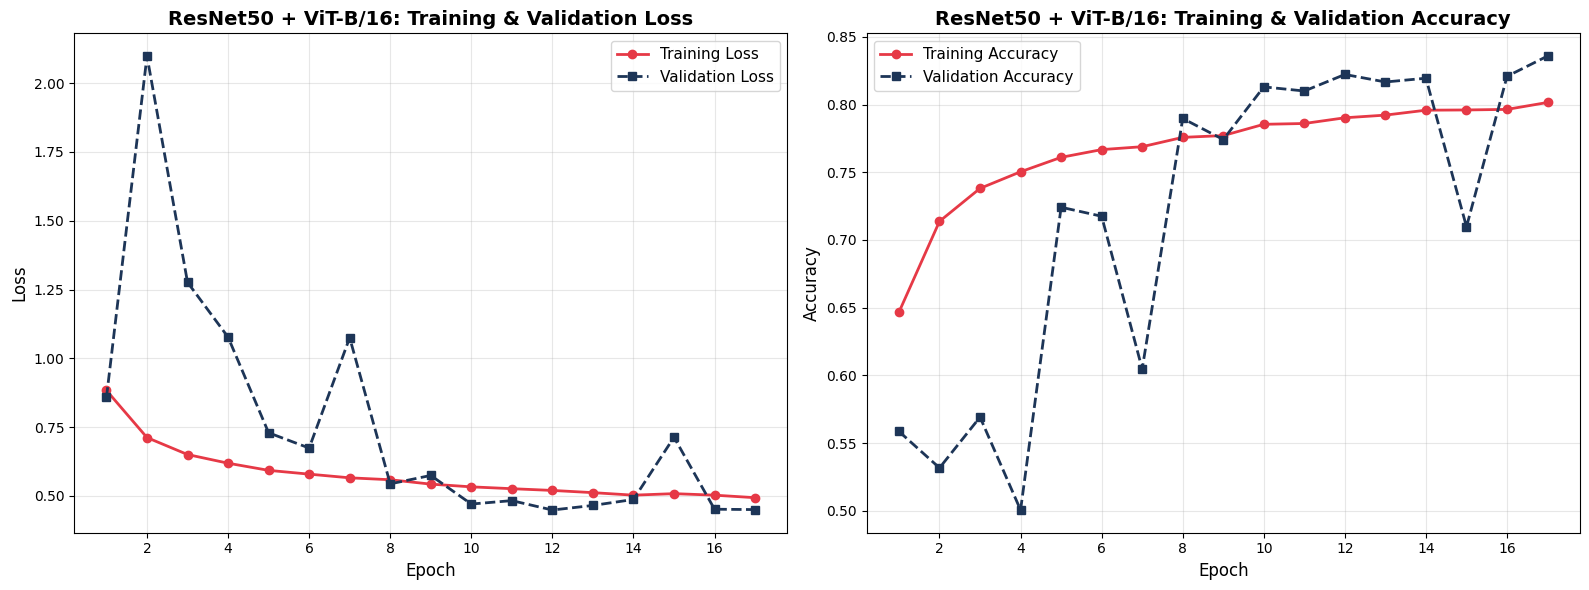


📊 EVALUATION ON VALIDATION SET
57/57 ━━━━━━━━━━━━━━━━━━━━ 60s 929ms/step

📈 PERFORMANCE METRICS
Accuracy:  82.22%
Precision: 82.30%
Recall:    82.22%
F1-Score:  82.21%

⏱️  Inference Time: 60.62s
⚡ Avg Time per Sample: 16.84ms

📋 DETAILED CLASSIFICATION REPORT
                   precision    recall  f1-score   support

     one_molecule     0.9123    0.9017    0.9070      1200
        reactions     0.7840    0.7408    0.7618      1200
several_molecules     0.7727    0.8242    0.7976      1200

         accuracy                         0.8222      3600
        macro avg     0.8230    0.8222    0.8221      3600
     weighted avg     0.8230    0.8222    0.8221      3600



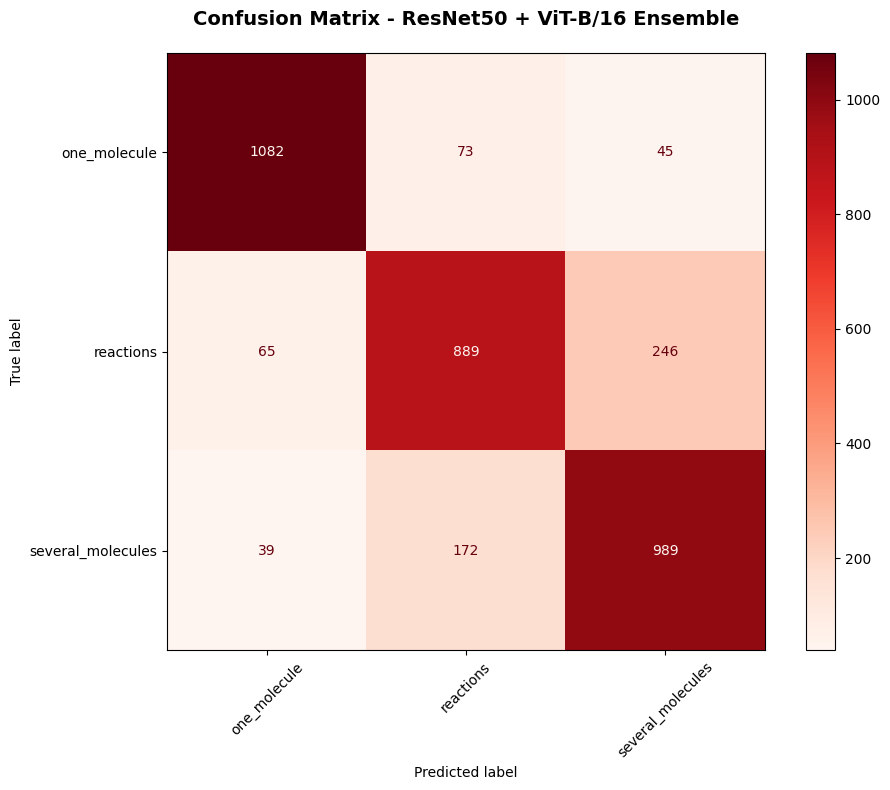


🎉 ENSEMBLE MODEL 2 EXECUTION COMPLETE!
Model: ResNet50 + ViT-B/16
Training Time: 188m 12s
Final Validation Accuracy: 82.22%
F1-Score: 82.21%


In [ ]:
"""
Ensemble Model 2: ResNet50 + ViT-B/16
Chemical Image Classification
GPU-Optimized for Kaggle T4
"""

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import precision_score, recall_score, f1_score
import random
import time

# GPU Configuration and Verification
print("="*70)
print("GPU CONFIGURATION CHECK")
print("="*70)
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"✅ GPU Available: {len(gpus)} device(s)")
    for gpu in gpus:
        print(f"   - {gpu}")
    # Enable memory growth to prevent OOM
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print("✅ Memory growth enabled")
else:
    print("⚠️  No GPU detected! Running on CPU")

print(f"\nTensorFlow version: {tf.__version__}")
print(f"Keras version: {keras.__version__}")

# Check if GPU is being used
print(f"Built with CUDA: {tf.test.is_built_with_cuda()}")
print(f"GPU Available for TensorFlow: {tf.test.is_gpu_available()}")

# Set seeds
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
print(f"\n🎲 Global seed set to: {SEED}")

# Configuration
TRAIN_DIR = "/kaggle/input/chemical-image-preprocessed/Preprocessed/train"
VAL_DIR = "/kaggle/input/chemical-image-preprocessed/Preprocessed/validation"
TEST_DIR = "/kaggle/input/chemical-image-preprocessed/Preprocessed/test"
IMG_SIZE = (224, 224)
BATCH_SIZE = 64
EPOCHS = 20
LEARNING_RATE = 0.0001

print("\n" + "="*70)
print("TRAINING CONFIGURATION")
print("="*70)
print(f"Image Size: {IMG_SIZE}")
print(f"Batch Size: {BATCH_SIZE}")
print(f"Epochs: {EPOCHS}")
print(f"Learning Rate: {LEARNING_RATE}")

# Data generators
print("\n" + "="*70)
print("LOADING DATA")
print("="*70)

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=SEED
)

val_generator = val_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

num_classes = len(train_generator.class_indices)
class_names = list(train_generator.class_indices.keys())
print(f"\n📁 Dataset Info:")
print(f"   Classes: {class_names}")
print(f"   Number of classes: {num_classes}")
print(f"   Training samples: {train_generator.n}")
print(f"   Validation samples: {val_generator.n}")

# Build Vision Transformer B/16
def create_vit_b16(input_shape, num_classes):
    """Vision Transformer Base/16 architecture"""
    inputs = layers.Input(shape=input_shape)

    # Patch embedding (16x16 patches)
    patch_size = 16
    num_patches = (input_shape[0] // patch_size) * (input_shape[1] // patch_size)
    projection_dim = 768

    # Create patches
    patches = layers.Conv2D(projection_dim, kernel_size=patch_size, strides=patch_size, padding='valid')(inputs)
    patches = layers.Reshape((num_patches, projection_dim))(patches)

    # Position embeddings
    positions = tf.range(start=0, limit=num_patches, delta=1)
    pos_embedding = layers.Embedding(input_dim=num_patches, output_dim=projection_dim)(positions)
    x = patches + pos_embedding

    # Transformer encoder blocks (10 blocks for efficiency)
    num_transformer_blocks = 10
    num_heads = 12
    mlp_dim = 3072

    for _ in range(num_transformer_blocks):
        # Layer normalization
        x1 = layers.LayerNormalization(epsilon=1e-6)(x)

        # Multi-head attention
        attention_output = layers.MultiHeadAttention(
            num_heads=num_heads,
            key_dim=projection_dim // num_heads,
            dropout=0.1
        )(x1, x1)

        # Skip connection
        x2 = layers.Add()([attention_output, x])

        # Layer normalization
        x3 = layers.LayerNormalization(epsilon=1e-6)(x2)

        # MLP
        x3 = layers.Dense(mlp_dim, activation=tf.nn.gelu)(x3)
        x3 = layers.Dropout(0.1)(x3)
        x3 = layers.Dense(projection_dim)(x3)
        x3 = layers.Dropout(0.1)(x3)

        # Skip connection
        x = layers.Add()([x3, x2])

    # Final layer normalization
    x = layers.LayerNormalization(epsilon=1e-6)(x)
    x = layers.GlobalAveragePooling1D()(x)

    return Model(inputs=inputs, outputs=x, name='ViT_B16')

# Build Ensemble Model
def create_ensemble_model(input_shape, num_classes):
    """ResNet50 + ViT-B/16 Ensemble"""
    inputs = layers.Input(shape=input_shape)

    # Branch 1: ResNet50 (CNN with Residual Connections)
    resnet = ResNet50(
        include_top=False,
        weights='imagenet',
        input_shape=input_shape,
        pooling='avg'
    )
    resnet.trainable = False  # Freeze initially
    resnet_output = resnet(inputs)

    # Branch 2: ViT-B/16 (Transformer)
    vit_model = create_vit_b16(input_shape, num_classes)
    vit_output = vit_model(inputs)

    # Fusion Layer
    concat = layers.Concatenate(name='feature_fusion')([resnet_output, vit_output])

    # Classification Head
    x = layers.Dense(512, activation='relu', name='fusion_dense1')(concat)
    x = layers.BatchNormalization(name='fusion_bn1')(x)
    x = layers.Dropout(0.4, name='fusion_dropout1')(x)

    x = layers.Dense(256, activation='relu', name='fusion_dense2')(x)
    x = layers.BatchNormalization(name='fusion_bn2')(x)
    x = layers.Dropout(0.3, name='fusion_dropout2')(x)

    outputs = layers.Dense(num_classes, activation='softmax', name='output')(x)

    return Model(inputs=inputs, outputs=outputs, name='ResNet50_ViT_Ensemble')

# Create model
print("\n" + "="*70)
print("BUILDING MODEL: ResNet50 + ViT-B/16")
print("="*70)

model = create_ensemble_model(IMG_SIZE + (3,), num_classes)

# Compile model
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Model summary
print("\n📋 Model Summary:")
model.summary()

# Plot model architecture
print("\n🎨 Generating model architecture diagram...")
try:
    tf.keras.utils.plot_model(
        model,
        to_file='resnet50_vit_ensemble_architecture.png',
        show_shapes=True,
        show_layer_names=True,
        show_dtype=True,
        dpi=96,
        expand_nested=False
    )
    print("✅ Architecture saved as 'resnet50_vit_ensemble_architecture.png'")
except Exception as e:
    print(f"⚠️  Could not save architecture diagram: {e}")

# Callbacks
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    )
]

# Training
print("\n" + "="*70)
print("🚀 STARTING TRAINING")
print("="*70)

start_time = time.time()

history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=callbacks,
    verbose=1
)

training_time = time.time() - start_time

print("\n" + "="*70)
print("✅ TRAINING COMPLETE!")
print("="*70)
print(f"⏱️  Total Training Time: {training_time//60:.0f}m {training_time%60:.0f}s")

# Plot training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

epochs_range = range(1, len(history.history['loss']) + 1)

ax1.plot(epochs_range, history.history['loss'], 'o-', color='#E63946', label='Training Loss', linewidth=2, markersize=6)
ax1.plot(epochs_range, history.history['val_loss'], 's--', color='#1D3557', label='Validation Loss', linewidth=2, markersize=6)
ax1.set_title("ResNet50 + ViT-B/16: Training & Validation Loss", fontsize=14, fontweight='bold')
ax1.set_xlabel("Epoch", fontsize=12)
ax1.set_ylabel("Loss", fontsize=12)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

ax2.plot(epochs_range, history.history['accuracy'], 'o-', color='#E63946', label='Training Accuracy', linewidth=2, markersize=6)
ax2.plot(epochs_range, history.history['val_accuracy'], 's--', color='#1D3557', label='Validation Accuracy', linewidth=2, markersize=6)
ax2.set_title("ResNet50 + ViT-B/16: Training & Validation Accuracy", fontsize=14, fontweight='bold')
ax2.set_xlabel("Epoch", fontsize=12)
ax2.set_ylabel("Accuracy", fontsize=12)
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('resnet50_vit_training_history.png', dpi=150, bbox_inches='tight')
plt.show()

# Evaluation
print("\n" + "="*70)
print("📊 EVALUATION ON VALIDATION SET")
print("="*70)

val_generator.reset()
eval_start = time.time()
y_pred_probs = model.predict(val_generator, verbose=1)
eval_time = time.time() - eval_start

y_pred = np.argmax(y_pred_probs, axis=1)
y_true = val_generator.classes

# Metrics
accuracy = 100 * np.sum(y_pred == y_true) / len(y_true)
precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)

print(f"\n{'='*70}")
print("📈 PERFORMANCE METRICS")
print(f"{'='*70}")
print(f"Accuracy:  {accuracy:.2f}%")
print(f"Precision: {precision*100:.2f}%")
print(f"Recall:    {recall*100:.2f}%")
print(f"F1-Score:  {f1*100:.2f}%")
print(f"\n⏱️  Inference Time: {eval_time:.2f}s")
print(f"⚡ Avg Time per Sample: {eval_time/len(y_true)*1000:.2f}ms")

print("\n" + "="*70)
print("📋 DETAILED CLASSIFICATION REPORT")
print("="*70)
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(cmap='Reds', ax=ax, xticks_rotation=45, values_format='d')
plt.title("Confusion Matrix - ResNet50 + ViT-B/16 Ensemble", fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('resnet50_vit_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Final Summary
print("\n" + "="*70)
print("🎉 ENSEMBLE MODEL 2 EXECUTION COMPLETE!")
print("="*70)
print(f"Model: ResNet50 + ViT-B/16")
print(f"Training Time: {training_time//60:.0f}m {training_time%60:.0f}s")
print(f"Final Validation Accuracy: {accuracy:.2f}%")
print(f"F1-Score: {f1*100:.2f}%")
print("="*70)